In [28]:
# Import required libraries
import pandas as pd 
import numpy as numpy 
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df=pd.read_csv("C:/Users/ACER/Downloads/SMS_SPAM detection.csv")

In [32]:
df

,target,text
0,spam,Congratulations! You've been selected for a lu...
1,spam,URGENT: Your account has been compromised. Cli...
2,spam,You've won a free iPhone! Claim your prize by ...
3,spam,Act now and receive a 50% discount on all purc...
4,spam,Important notice: Your subscription will expir...
...,...,...
10956,spam,Hey little one! Exciting news! Mama and baby a...
10957,spam,Amazing DATA deals on your Pulse Plan today! D...
10958,spam,Special offer just for you! Get 1GB @15 bob va...
10959,spam,NEW ARRIVAL - JUNE 23RD Dresses @ 300; Kondel...


In [34]:
df.columns

Index(['target', 'text'], dtype='object')

In [36]:
#to find the no. of records & columns
df.shape

(10961, 2)

In [38]:
# use the info method to find the number of non null entries and data Type of each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10961 entries, 0 to 10960
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  10961 non-null  object
 1   text    10961 non-null  object
dtypes: object(2)
memory usage: 171.4+ KB


In [40]:
#to check the null values in a column
df.isnull().sum()

target    0
text      0
dtype: int64

In [42]:
#to check if kisi column m koi null values hai ya nahi
df.isnull().values.any()

False

In [44]:
#check dupicate values
df.duplicated().sum()

674

In [46]:
df.drop_duplicates(inplace=True)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10287 entries, 0 to 10960
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  10287 non-null  object
 1   text    10287 non-null  object
dtypes: object(2)
memory usage: 241.1+ KB


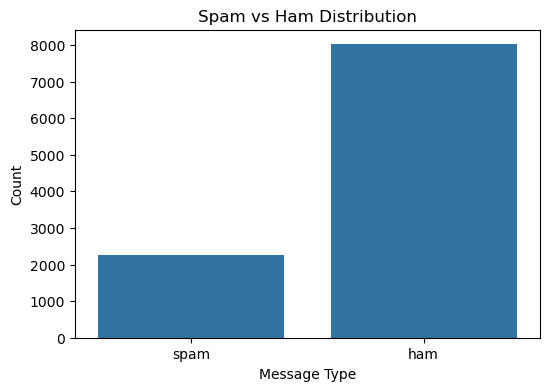

In [54]:
# Label Distribution
# Create figure
plt.figure(figsize=(6,4))
# Count how many Spam and Ham messages are present
sns.countplot(x='target', data=df)
# Graph title
plt.title("Spam vs Ham Distribution")
# X-axis label
plt.xlabel("Message Type")
# Y-axis label
plt.ylabel("Count")
# Show graph
plt.show()

In [56]:
from sklearn.preprocessing import LabelEncoder

LABEL ENCODING

In [58]:
#store encoder in variable le
le=LabelEncoder()

In [60]:
# Convert the target column into numerical values
df['target'] = le.fit_transform(df['target'])

In [62]:
df
#ham=0
#spam=1

,target,text
0,1,Congratulations! You've been selected for a lu...
1,1,URGENT: Your account has been compromised. Cli...
2,1,You've won a free iPhone! Claim your prize by ...
3,1,Act now and receive a 50% discount on all purc...
4,1,Important notice: Your subscription will expir...
...,...,...
10956,1,Hey little one! Exciting news! Mama and baby a...
10957,1,Amazing DATA deals on your Pulse Plan today! D...
10958,1,Special offer just for you! Get 1GB @15 bob va...
10959,1,NEW ARRIVAL - JUNE 23RD Dresses @ 300; Kondel...


In [64]:
# Logistic Regression is a supervised machine learning algorithm.
# It is used for classification problems such as Spam Detection.
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [66]:
# List of categorical columns
col = ['target']
# Apply Label Encoding on the categorical column
for c in col:
    df[c] = le.fit_transform(df[c])

In [68]:
df

,target,text
0,1,Congratulations! You've been selected for a lu...
1,1,URGENT: Your account has been compromised. Cli...
2,1,You've won a free iPhone! Claim your prize by ...
3,1,Act now and receive a 50% discount on all purc...
4,1,Important notice: Your subscription will expir...
...,...,...
10956,1,Hey little one! Exciting news! Mama and baby a...
10957,1,Amazing DATA deals on your Pulse Plan today! D...
10958,1,Special offer just for you! Get 1GB @15 bob va...
10959,1,NEW ARRIVAL - JUNE 23RD Dresses @ 300; Kondel...


In [70]:
# X contains the input feature (SMS text)
X = df.iloc[:,1].values
#1=second column

In [72]:
X

array(["Congratulations! You've been selected for a luxury vacation getaway. Claim your prize now!",
       'URGENT: Your account has been compromised. Click here to reset your password immediately.',
       "You've won a free iPhone! Claim your prize by clicking on this link now.",
       ...,
       'Special offer just for you! Get 1GB @15 bob valid for 1 hour ! Dial *544# and select Amazing data to get this offer!',
       'NEW ARRIVAL - JUNE 23RD  Dresses @ 300; Kondele Branch  Dresses @ 200; Lolwe Branch  Dresses @ 100; Kwa Makaa Branch  Save our number 0759885283 to view  new outfits on WhatsApp Status  FROM TREPA',
       'Coureen, did you know that saving on Timiza increases your chances of qualifying for a loan limit? Start now and enjoy a high interest rate of 9% per annum. Dial *848# or use the App to save.Stop dial *456*9*5#'],
      dtype=object)

In [74]:
# Y contains the target variable (Spam/Ham)
Y = df.iloc[:,0].values

In [76]:
Y

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

Logistic Regression

In [37]:
# # logistic regression is a supervised learning technique
# and it is used for classification problems and 
# it predict whether the output is in yes/no ,  pass/fail or spam /not spam, desease/ not desease

In [78]:
df

,target,text
0,1,Congratulations! You've been selected for a lu...
1,1,URGENT: Your account has been compromised. Cli...
2,1,You've won a free iPhone! Claim your prize by ...
3,1,Act now and receive a 50% discount on all purc...
4,1,Important notice: Your subscription will expir...
...,...,...
10956,1,Hey little one! Exciting news! Mama and baby a...
10957,1,Amazing DATA deals on your Pulse Plan today! D...
10958,1,Special offer just for you! Get 1GB @15 bob va...
10959,1,NEW ARRIVAL - JUNE 23RD Dresses @ 300; Kondel...


STANDARDISATION


In [52]:
#it works only for numerical values islie we'll convert first bcz abhi X mai "congrats you've won h
#(x-mean)/standardisation

In [80]:
# Convert text messages into numerical values using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['text']).toarray()
# Target Variable
Y = df['target'].values
# Congratulations  -> 0.67
# won              -> 0.51
# prize            -> 0.72

In [82]:
df.shape

(10287, 2)

In [84]:
# 70% = Training
# 30% = Testing
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.3, random_state=41)

In [90]:
#Sab features ko same scale par convert kiya.
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)

In [86]:
from sklearn.linear_model import LogisticRegression 
#classification model

In [87]:
log=LogisticRegression()

In [88]:
# Train the Logistic Regression model
log.fit(X_train,Y_train)

LogisticRegression()

In [95]:
# Predict whether the message is Spam or Ham
Y_pred=log.predict(X_test)

In [97]:
#display karo predicted output ko
Y_pred

array([0, 0, 0, ..., 1, 0, 1], dtype=int64)

In [99]:
# Display the actual target values
Y_test

array([0, 1, 0, ..., 1, 0, 1], dtype=int64)

In [101]:
# Display prediction probabilities ki modle kitna sure h
log.predict_proba(X_test)

array([[9.99791081e-01, 2.08919265e-04],
       [9.36155893e-01, 6.38441071e-02],
       [9.98977445e-01, 1.02255511e-03],
       ...,
       [4.09321567e-03, 9.95906784e-01],
       [9.99997852e-01, 2.14770217e-06],
       [4.03730886e-05, 9.99959627e-01]])

In [103]:
#Prediction aur actual values compare karo
from sklearn.metrics import confusion_matrix
confusion_matrix(Y_test, Y_pred)

array([[2239,  171],
       [  46,  631]], dtype=int64)

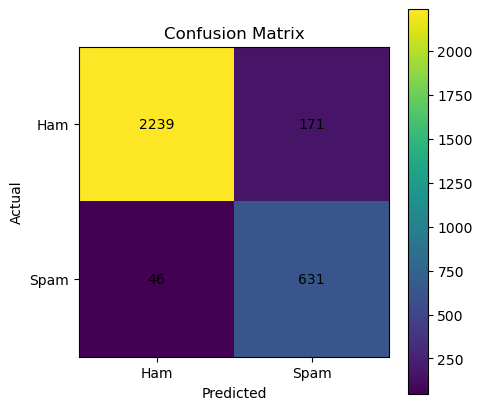

In [115]:
import numpy as np
# Create confusion matrix using actual and predicted values
cm = confusion_matrix(Y_test, Y_pred)
# Create figure
plt.figure(figsize=(5,5))
# Display confusion matrix as an image
plt.imshow(cm, interpolation='nearest')
# Graph title
plt.title("Confusion Matrix")
# Show color scale
plt.colorbar()
# Create tick positions
tick_marks = np.arange(2)
# Set x-axis labels
plt.xticks(tick_marks, ['Ham', 'Spam'])
# Set y-axis labels
plt.yticks(tick_marks, ['Ham', 'Spam'])
# Axis labels
plt.xlabel("Predicted")
plt.ylabel("Actual")
# Display values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

# Show graph
plt.show()

In [105]:
#to check ki model kitni baar sahi prediction kar raha hai
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

0.9297052154195011

In [107]:
#to check detailed perfromance of model
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95      2410
           1       0.79      0.93      0.85       677

    accuracy                           0.93      3087
   macro avg       0.88      0.93      0.90      3087
weighted avg       0.94      0.93      0.93      3087

